# Setting Annotation Comparison

Loads annotation output from all annotators on the setting task and surfaces instances where ratings diverge most.

**Dimensions** (1–5 Likert): concreteness, temporal grounding, spatial grounding, sensory  
**Annotators**: tejo9855, roda9210, mppauk (+ zeet, 3 instances)  

Key outputs:
- Agreement metrics per dimension and annotator pair
- Rating distributions per annotator
- Per-instance disagreement scores — sorted to surface highest-disagreement examples
- Rich text display of top disagreement instances

In [1]:
import json
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from itertools import combinations
from IPython.display import display, HTML

try:
    import krippendorff
    HAS_KRIPPENDORFF = True
except ImportError:
    HAS_KRIPPENDORFF = False
    print('krippendorff not installed — α will be skipped. Run: pip install krippendorff')

## Configuration

In [6]:
RESULTS_DIR = '../annotation_output/results'
CSV_PATH    = '../data/dolma_combined_final_sample_700_with_llm_summary_safeid_with_spans.csv'

ANNOTATORS = ['tejo9855', 'roda9210', 'mppauk']

DIMS = [
    'setting_concreteness',
    'setting_temporal_grounding',
    'setting_spatial_grounding',
    'setting_sensory',
]
DIM_LABELS = {
    'setting_concreteness':        'Concreteness',
    'setting_temporal_grounding':  'Temporal',
    'setting_spatial_grounding':   'Spatial',
    'setting_sensory':             'Sensory',
}

TOP_N_DISAGREE = 30   # how many high-disagreement instances to render in full
MIN_PAIRS = 3         # minimum shared instances to report agreement metrics

## Load Data

In [7]:
csv.field_size_limit(10**7)
with open(CSV_PATH) as f:
    rows_in_order = list(csv.DictReader(f))

text_rows    = {r['safe_instance_id']: r for r in rows_in_order}
dataset_order = [r['safe_instance_id'] for r in rows_in_order]
print(f'Dataset: {len(dataset_order)} instances')

def parse_likert(val):
    """Last entry per schema wins (Potato stores an edit log)."""
    result = {}
    for entry in val:
        result[entry[0]['schema']] = int(entry[0]['name'])
    return result

annotator_data = {}   # annotator -> {inst_id -> {dim -> int}}
for ann in ANNOTATORS:
    path = f'{RESULTS_DIR}/{ann}/user_state.json'
    try:
        with open(path) as f:
            state = json.load(f)
        annotator_data[ann] = {
            inst_id: parse_likert(val)
            for inst_id, val in state['instance_id_to_label_to_value'].items()
        }
        print(f'  {ann}: {len(annotator_data[ann])} instances')
    except FileNotFoundError:
        annotator_data[ann] = {}
        print(f'  {ann}: file not found — skipping')

active_annotators = [a for a in ANNOTATORS if annotator_data[a]]

Dataset: 679 instances
  tejo9855: 21 instances
  roda9210: 21 instances
  mppauk: 13 instances


## Agreement Metrics

Computed per annotator pair, per dimension.  
Metrics: exact match, within-1 (|diff| ≤ 1), MAE, Krippendorff's α (interval), ICC(2,1).

In [8]:
def exact_match(pairs):
    if not pairs: return None
    return sum(a == b for a, b in pairs) / len(pairs)

def within_one(pairs):
    if not pairs: return None
    return sum(abs(a - b) <= 1 for a, b in pairs) / len(pairs)

def mae(pairs):
    if not pairs: return None
    return float(np.mean([abs(a - b) for a, b in pairs]))

def alpha_kripp(pairs):
    if not HAS_KRIPPENDORFF or len(pairs) < 2: return None
    y1, y2 = zip(*pairs)
    if len(set(y1) | set(y2)) < 2: return None
    data = np.array([list(y1), list(y2)], dtype=float)
    try:
        return krippendorff.alpha(data, level_of_measurement='interval')
    except Exception:
        return None

def icc_two_way(pairs):
    if len(pairs) < 2: return None
    data = np.array(pairs, dtype=float)
    n, k = data.shape
    grand_mean    = data.mean()
    subject_means = data.mean(axis=1)
    rater_means   = data.mean(axis=0)
    SS_subjects = k * ((subject_means - grand_mean) ** 2).sum()
    SS_raters   = n * ((rater_means   - grand_mean) ** 2).sum()
    SS_total    = ((data - grand_mean) ** 2).sum()
    SS_error    = SS_total - SS_subjects - SS_raters
    MS_subjects = SS_subjects / (n - 1)
    MS_raters   = SS_raters   / (k - 1)
    MS_error    = SS_error    / ((n - 1) * (k - 1))
    denom = MS_subjects + (k - 1) * MS_error + k * (MS_raters - MS_error) / n
    if denom == 0: return None
    return (MS_subjects - MS_error) / denom

def fmt(v, pct=False):
    if v is None: return '<span style="color:#bbb">—</span>'
    return f'{v*100:.1f}%' if pct else f'{v:.3f}'

In [9]:
ann_pairs = list(combinations(active_annotators, 2))
table_rows = []

for ann1, ann2 in ann_pairs:
    shared = set(annotator_data[ann1]) & set(annotator_data[ann2])
    shared_ordered = [i for i in dataset_order if i in shared]
    for dim in DIMS:
        pairs = []
        for inst_id in shared_ordered:
            v1 = annotator_data[ann1][inst_id].get(dim)
            v2 = annotator_data[ann2][inst_id].get(dim)
            if v1 is not None and v2 is not None:
                pairs.append((v1, v2))
        n = len(pairs)
        if n >= MIN_PAIRS:
            row = dict(
                pair=f'{ann1} / {ann2}', dim=DIM_LABELS[dim], n=n,
                em=exact_match(pairs), w1=within_one(pairs),
                mae=mae(pairs), alpha=alpha_kripp(pairs),
                icc=icc_two_way(pairs),
            )
        else:
            row = dict(pair=f'{ann1} / {ann2}', dim=DIM_LABELS[dim], n=n,
                       em=None, w1=None, mae=None, alpha=None, icc=None)
        table_rows.append(row)

header = (
    '<tr style="background:#f0f0f0">'  
    '<th style="padding:6px 12px;text-align:left">Annotator pair</th>'
    '<th style="padding:6px 12px;text-align:left">Dimension</th>'
    '<th style="padding:6px 12px">N</th>'
    '<th style="padding:6px 12px">Exact match</th>'
    '<th style="padding:6px 12px">Within 1</th>'
    '<th style="padding:6px 12px">MAE</th>'
    '<th style="padding:6px 12px">Krippendorff α</th>'
    '<th style="padding:6px 12px">ICC(2,1)</th>'
    '</tr>'
)

rows_html = ''
prev_pair = None
for row in table_rows:
    pair_cell = ''
    if row['pair'] != prev_pair:
        # count how many dims in this pair for rowspan
        span = sum(1 for r in table_rows if r['pair'] == row['pair'])
        pair_cell = f'<td style="padding:6px 12px;font-weight:bold;vertical-align:top" rowspan="{span}">{row["pair"]}</td>'
    prev_pair = row['pair']
    rows_html += (
        f'<tr style="border-top:1px solid #eee">'
        f'{pair_cell}'
        f'<td style="padding:6px 12px">{row["dim"]}</td>'
        f'<td style="padding:6px 12px;text-align:center">{row["n"]}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["em"], pct=True)}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["w1"], pct=True)}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["mae"])}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["alpha"])}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["icc"])}</td>'
        f'</tr>'
    )

notes = (
    '<p style="color:#777;font-size:0.8em;margin-top:10px;line-height:1.6">'
    '<b>Within 1</b>: fraction of pairs differing by ≤1 point.<br>'
    '<b>MAE</b>: mean absolute difference — directly interpretable scale of disagreement.<br>'
    '<b>Krippendorff α</b>: interval metric for ordinal data; robust to unequal N per annotator.<br>'
    '<b>ICC(2,1)</b>: two-way random effects; credits agreement even when one annotator rates systematically higher/lower.<br>'
    f'Rows with N &lt; {MIN_PAIRS} show — (insufficient shared instances).'
    '</p>'
)

display(HTML(
    '<div style="font-family:sans-serif">'
    '<table style="border-collapse:collapse;font-size:0.92em">'
    f'<thead>{header}</thead><tbody>{rows_html}</tbody>'
    '</table>' + notes + '</div>'
))

## Rating Distributions

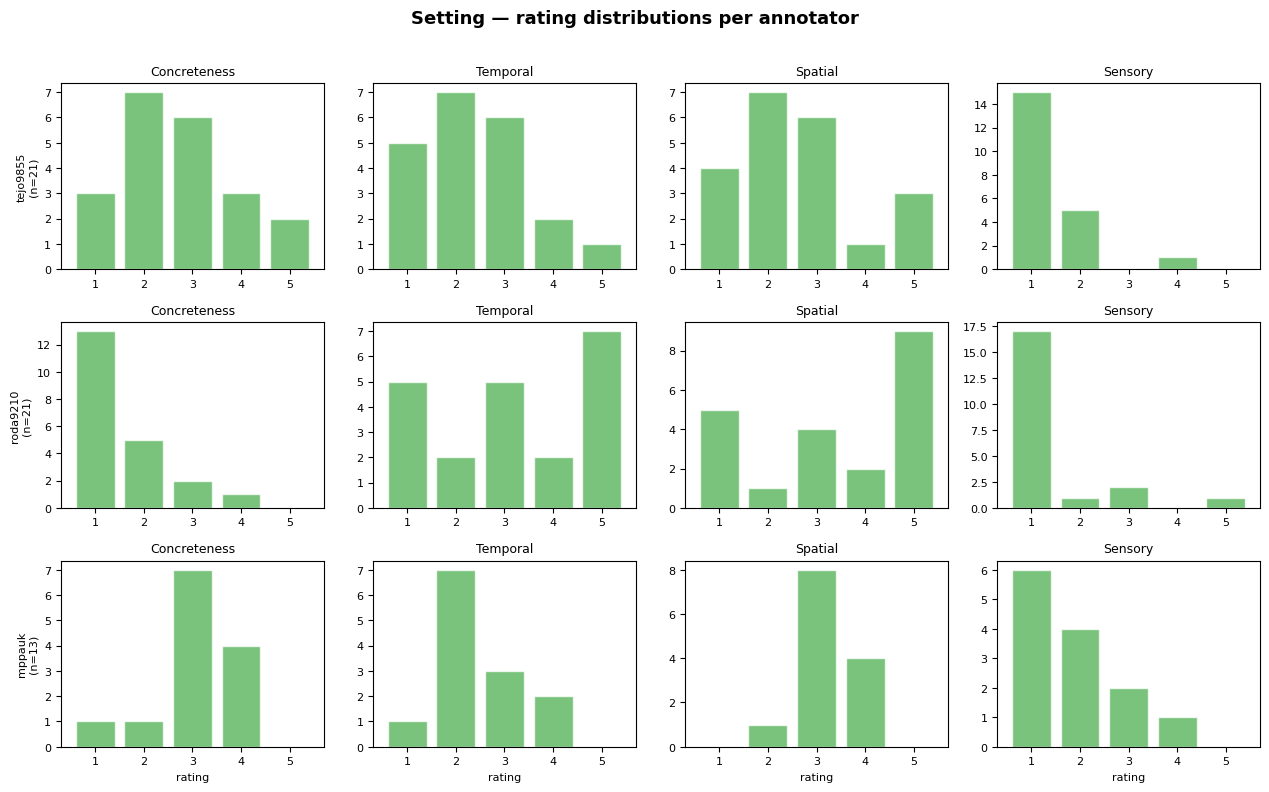

In [10]:
n_anns = len(active_annotators)
n_dims = len(DIMS)
fig, axes = plt.subplots(n_anns, n_dims, figsize=(3.2 * n_dims, 2.6 * n_anns),
                         sharey=False, squeeze=False)
fig.suptitle('Setting — rating distributions per annotator', fontsize=13, fontweight='bold', y=1.01)

for ai, ann in enumerate(active_annotators):
    ann_d = annotator_data[ann]
    for di, dim in enumerate(DIMS):
        ax = axes[ai][di]
        vals = [ann_d[inst].get(dim) for inst in ann_d
                if ann_d[inst] is not None and ann_d[inst].get(dim) is not None]
        counts = [vals.count(v) for v in range(1, 6)]
        ax.bar(range(1, 6), counts, color='#4caf50', alpha=0.75, edgecolor='white')
        ax.set_xticks(range(1, 6))
        ax.set_xlim(0.3, 5.7)
        ax.set_title(DIM_LABELS[dim], fontsize=9)
        if di == 0:
            ax.set_ylabel(f'{ann}\n(n={len(vals)})', fontsize=8)
        if ai == n_anns - 1:
            ax.set_xlabel('rating', fontsize=8)
        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

## Per-Instance Disagreement

For each instance annotated by at least two annotators, compute a **disagreement score** =
mean |rating_a − rating_b| across all (annotator pair × dimension) combinations where both
annotators provided a rating.  A score near 0 means perfect agreement; near 4 means maximum disagreement.

Instances are ranked by this score and the highest-disagreement ones are displayed in detail below.

In [11]:
# Build per-instance disagreement table
records = []

for inst_id in dataset_order:
    # Gather which active annotators have this instance
    annotated_by = [a for a in active_annotators if inst_id in annotator_data[a]]
    if len(annotated_by) < 2:
        continue

    diffs = []
    dim_max_diff = {}   # dim -> max pairwise diff for this instance
    for ann1, ann2 in combinations(annotated_by, 2):
        for dim in DIMS:
            v1 = annotator_data[ann1][inst_id].get(dim)
            v2 = annotator_data[ann2][inst_id].get(dim)
            if v1 is not None and v2 is not None:
                d = abs(v1 - v2)
                diffs.append(d)
                dim_max_diff[dim] = max(dim_max_diff.get(dim, 0), d)

    if not diffs:
        continue

    records.append(dict(
        inst_id=inst_id,
        annotators=annotated_by,
        score=float(np.mean(diffs)),
        max_diff=max(diffs),
        dim_max_diff=dim_max_diff,
    ))

records.sort(key=lambda r: r['score'], reverse=True)

print(f'{len(records)} instances with ≥2 annotators')
if records:
    scores = [r['score'] for r in records]
    print(f'Disagreement score — mean: {np.mean(scores):.2f}, '
          f'median: {np.median(scores):.2f}, max: {np.max(scores):.2f}')

21 instances with ≥2 annotators
Disagreement score — mean: 1.02, median: 1.00, max: 2.00


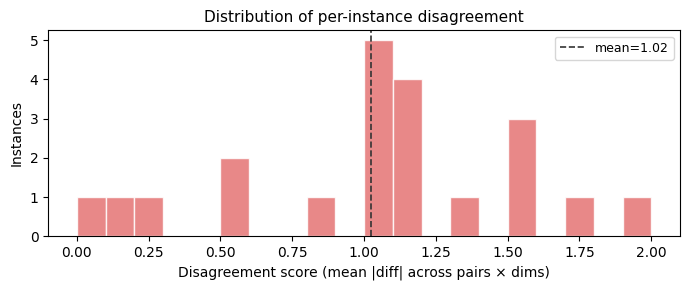

In [12]:
scores = [r['score'] for r in records]
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(scores, bins=20, color='#e57373', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(scores), color='#333', linestyle='--', linewidth=1.2, label=f'mean={np.mean(scores):.2f}')
ax.set_xlabel('Disagreement score (mean |diff| across pairs × dims)', fontsize=10)
ax.set_ylabel('Instances', fontsize=10)
ax.set_title('Distribution of per-instance disagreement', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
# Compact ranked table of all shared instances
def rating_cell(val, spread=None):
    """Colored cell: green (5) → red (1), darker border if spread is large."""
    if val is None:
        return '<td style="padding:4px 8px;color:#bbb;text-align:center">—</td>'
    # interpolate: 1=red, 3=yellow, 5=green
    cmap = plt.cm.RdYlGn
    rgba = cmap((val - 1) / 4)
    hex_color = mcolors.to_hex(rgba)
    border = '2px solid #c00' if (spread is not None and spread >= 3) else '1px solid #ddd'
    return (f'<td style="padding:4px 8px;text-align:center;background:{hex_color};'
            f'color:#333;font-weight:bold;border:{border}">{val}</td>')

dim_short = [DIM_LABELS[d] for d in DIMS]

header_cells = (
    '<th style="padding:5px 8px;text-align:left">Score</th>'
    '<th style="padding:5px 8px;text-align:left">Instance</th>'
    '<th style="padding:5px 8px;text-align:left">Annotator</th>'
    + ''.join(f'<th style="padding:5px 8px">{d}</th>' for d in dim_short)
)

rows_html = ''
for rank, rec in enumerate(records):
    inst_id = rec['inst_id']
    # Score cell — spans all annotator rows
    n_anns_here = len(rec['annotators'])
    score_cell = (
        f'<td style="padding:5px 8px;font-weight:bold;vertical-align:middle;'
        f'text-align:center;font-size:1.05em" rowspan="{n_anns_here}">'
        f'{rec["score"]:.2f}</td>'
    )
    id_cell = (
        f'<td style="padding:5px 8px;font-size:0.75em;color:#888;vertical-align:middle" rowspan="{n_anns_here}">'
        f'{inst_id}</td>'
    )

    for ai, ann in enumerate(rec['annotators']):
        ratings = annotator_data[ann].get(inst_id, {})
        prefix = score_cell + id_cell if ai == 0 else ''
        ann_cell = f'<td style="padding:5px 8px;font-size:0.85em">{ann}</td>'
        dim_cells = ''.join(
            rating_cell(ratings.get(dim), rec['dim_max_diff'].get(dim))
            for dim in DIMS
        )
        rows_html += f'<tr style="border-top:1px solid #eee">{prefix}{ann_cell}{dim_cells}</tr>'

display(HTML(
    '<div style="font-family:sans-serif">'
    f'<p style="font-size:0.85em;color:#666">All {len(records)} shared instances ranked by disagreement. '
    'Red-outlined cells: max pairwise diff ≥ 3 on that dimension.</p>'
    '<table style="border-collapse:collapse;font-size:0.88em">'
    f'<thead><tr style="background:#f0f0f0">{header_cells}</tr></thead>'
    f'<tbody>{rows_html}</tbody>'
    '</table></div>'
))

## High-Disagreement Instances — Full Text View

The top-N most disagreed instances are rendered with the full passage text, LLM summary, and a rating grid so you can read the text and judge why annotators diverged.

In [14]:
def rating_badge(val):
    if val is None:
        return '<span style="color:#bbb">—</span>'
    cmap = plt.cm.RdYlGn
    rgba = cmap((val - 1) / 4)
    hex_color = mcolors.to_hex(rgba)
    return (
        f'<span style="display:inline-block;width:22px;height:22px;line-height:22px;'
        f'text-align:center;background:{hex_color};border-radius:4px;'
        f'font-weight:bold;font-size:0.9em;color:#333">{val}</span>'
    )


def display_instance(rec):
    inst_id = rec['inst_id']
    row = text_rows.get(inst_id, {})
    text = row.get('sampled_text', '(text not found)').replace('\n', '<br>')
    summary = row.get('llm_summary', '').replace('\n', ' ')
    source = row.get('source', '')

    # Rating grid
    header_row = '<tr style="background:#f5f5f5"><th style="padding:4px 10px">Annotator</th>' + \
        ''.join(f'<th style="padding:4px 10px">{DIM_LABELS[d]}</th>' for d in DIMS) + '</tr>'

    data_rows = ''
    for ann in rec['annotators']:
        ratings = annotator_data[ann].get(inst_id, {})
        cells = ''.join(f'<td style="padding:4px 10px;text-align:center">{rating_badge(ratings.get(d))}</td>' for d in DIMS)
        data_rows += f'<tr><td style="padding:4px 10px;font-size:0.85em">{ann}</td>{cells}</tr>'

    # Per-dimension spread row
    spread_cells = ''
    for dim in DIMS:
        vals = [annotator_data[a][inst_id].get(dim) for a in rec['annotators']
                if annotator_data[a].get(inst_id, {}).get(dim) is not None]
        if len(vals) >= 2:
            sp = max(vals) - min(vals)
            color = '#c00' if sp >= 3 else ('#e67e22' if sp >= 2 else '#888')
            spread_cells += f'<td style="padding:4px 10px;text-align:center;font-size:0.8em;color:{color}">Δ{sp}</td>'
        else:
            spread_cells += '<td style="padding:4px 10px;text-align:center;color:#bbb">—</td>'
    data_rows += f'<tr style="border-top:1px solid #ddd"><td style="padding:4px 10px;font-size:0.8em;color:#888">spread</td>{spread_cells}</tr>'

    grid = (
        f'<table style="border-collapse:collapse;font-size:0.9em;margin-top:8px">'
        f'<thead>{header_row}</thead><tbody>{data_rows}</tbody></table>'
    )

    html = (
        '<div style="border:1px solid #ddd;border-radius:6px;padding:14px 18px;'
        'margin-bottom:22px;font-family:sans-serif">'
        f'<div style="display:flex;justify-content:space-between;align-items:baseline;margin-bottom:6px">'
        f'<span style="font-size:0.8em;color:#888">{inst_id} &nbsp;|&nbsp; {source}</span>'
        f'<span style="font-weight:bold;color:#c0392b">score: {rec["score"]:.2f}</span>'
        f'</div>'
        + (f'<div style="font-size:0.85em;color:#555;font-style:italic;margin-bottom:8px;'
           f'border-left:3px solid #aed6f1;padding-left:8px"><b>Summary:</b> {summary}</div>'
           if summary else '')
        + f'<div style="background:#fafafa;border-left:3px solid #ccc;padding:10px 14px;'
          f'font-size:0.93em;line-height:1.6;max-height:280px;overflow-y:auto">{text}</div>'
        + grid
        + '</div>'
    )
    display(HTML(html))


top = records[:TOP_N_DISAGREE]
print(f'Rendering top {len(top)} highest-disagreement instances (score threshold: {top[-1]["score"]:.2f})')
for rec in top:
    display_instance(rec)

Rendering top 21 highest-disagreement instances (score threshold: 0.00)


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,4,2,3,2
roda9210,3,4,1,5
spread,Δ1,Δ2,Δ2,Δ3


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,2,2,2,1
roda9210,1,5,5,1
spread,Δ1,Δ3,Δ3,Δ0


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,3,2,3,2
roda9210,1,1,1,1
mppauk,4,3,3,3
spread,Δ3,Δ2,Δ2,Δ2


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,5,3,4,2
roda9210,1,5,4,1
mppauk,3,2,3,2
spread,Δ4,Δ3,Δ1,Δ1


...

Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,2,3,2,1
roda9210,1,3,3,1
spread,Δ1,Δ0,Δ1,Δ0


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,2,2,3,1
roda9210,1,3,3,1
spread,Δ1,Δ1,Δ0,Δ0


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,1,1,1,1
roda9210,2,1,1,1
spread,Δ1,Δ0,Δ0,Δ0


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,2,2,3,1
roda9210,1,2,3,1
mppauk,2,2,3,1
spread,Δ1,Δ0,Δ0,Δ0


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,1,1,1,1
roda9210,1,1,1,1
spread,Δ0,Δ0,Δ0,Δ0


## Highest-Agreement Instances

For reference: instances where all annotators were closest to each other.

In [15]:
bottom = records[-10:][::-1]   # 10 most agreed, highest-agreement first
print(f'Rendering {len(bottom)} highest-agreement instances')
for rec in bottom:
    display_instance(rec)

Rendering 10 highest-agreement instances


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,1,1,1,1
roda9210,1,1,1,1
spread,Δ0,Δ0,Δ0,Δ0


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,2,2,3,1
roda9210,1,2,3,1
mppauk,2,2,3,1
spread,Δ1,Δ0,Δ0,Δ0


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,1,1,1,1
roda9210,2,1,1,1
spread,Δ1,Δ0,Δ0,Δ0


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,2,2,3,1
roda9210,1,3,3,1
spread,Δ1,Δ1,Δ0,Δ0


...

Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,2,1,2,1
roda9210,1,1,3,1
mppauk,3,2,3,2
spread,Δ2,Δ1,Δ1,Δ1


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,2,3,1,1
roda9210,2,4,2,3
spread,Δ0,Δ1,Δ1,Δ2


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,3,2,3,1
roda9210,3,3,5,3
mppauk,3,2,2,2
spread,Δ0,Δ1,Δ3,Δ2


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,3,3,2,1
roda9210,1,2,4,1
mppauk,3,1,3,1
spread,Δ2,Δ2,Δ2,Δ0


Annotator,Concreteness,Temporal,Spatial,Sensory
tejo9855,5,1,5,4
roda9210,4,1,5,1
mppauk,4,2,4,4
spread,Δ1,Δ1,Δ1,Δ3
